# Telecom Customer Churn & Retention
## 05 — Churn Modeling

This notebook develops and evaluates machine-learning models that predict whether a telecom customer will churn.

The modeling workflow:

- loads the train/test split created in `04_feature_engineering.ipynb`;
- rebuilds the same leakage-safe preprocessing pipeline;
- compares several classification models;
- evaluates models using metrics appropriate for an imbalanced churn problem;
- selects the strongest model using ROC-AUC;
- examines the most influential model features;
- generates churn probabilities for the held-out test set;
- exports predictions and model-performance results for the retention strategy stage.

### Models compared
1. Logistic Regression
2. Random Forest
3. Gradient Boosting

### Evaluation metrics
Because only about 26.5% of customers churn, accuracy alone is not sufficient.

The main metrics are:

- **ROC-AUC** — ability to rank churners above non-churners;
- **PR-AUC** — performance on the minority churn class;
- **Recall** — share of actual churners correctly identified;
- **Precision** — share of predicted churners who actually churn;
- **F1 Score** — balance between precision and recall;
- **Accuracy** — included for completeness.

The final business workflow will rely primarily on **predicted churn probability**, not only the 0/1 class prediction.


In [1]:
from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 1. Load train/test data and feature metadata


In [2]:
candidate_dirs = [
    Path("../data/processed"),
    Path("data/processed"),
    Path("."),
    Path("/mnt/data/processed"),
]

DATA_DIR = next(
    (
        d for d in candidate_dirs
        if (d / "X_train.csv").exists()
        and (d / "X_test.csv").exists()
        and (d / "y_train.csv").exists()
        and (d / "y_test.csv").exists()
    ),
    None
)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Feature-engineering outputs were not found. "
        "Run 04_feature_engineering.ipynb first."
    )

X_train_export = pd.read_csv(DATA_DIR / "X_train.csv")
X_test_export = pd.read_csv(DATA_DIR / "X_test.csv")
y_train_export = pd.read_csv(DATA_DIR / "y_train.csv")
y_test_export = pd.read_csv(DATA_DIR / "y_test.csv")

with open(DATA_DIR / "model_feature_metadata.json", "r") as f:
    metadata = json.load(f)

TARGET = metadata["target"]

train_index = X_train_export["source_index"].copy()
test_index = X_test_export["source_index"].copy()

X_train = X_train_export.drop(columns=["source_index"])
X_test = X_test_export.drop(columns=["source_index"])

y_train = y_train_export[TARGET].copy()
y_test = y_test_export[TARGET].copy()

print(f"Loaded from: {DATA_DIR}")
print(f"Training rows: {len(X_train):,}")
print(f"Test rows:     {len(X_test):,}")
print(f"Predictors:    {X_train.shape[1]}")


Loaded from: ../data/processed
Training rows: 5,634
Test rows:     1,409
Predictors:    22


## 2. Rebuild the preprocessing pipeline

The preprocessing design matches the feature-engineering notebook:

- numeric features → median imputation + standardization;
- categorical features → most-frequent imputation + one-hot encoding.

Each model pipeline fits preprocessing only on the training data.


In [3]:
numeric_features = metadata["numeric_features"]
categorical_features = metadata["categorical_features"]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

print(f"Numeric features:     {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")


Numeric features:     6
Categorical features: 16


## 3. Define candidate models

Class imbalance is addressed directly for Logistic Regression and Random Forest using `class_weight="balanced"`.

Gradient Boosting is included as a nonlinear benchmark without class weighting.


In [4]:
RANDOM_STATE = 42

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE,
    ),
}

models


{'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
 'Random Forest': RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                        n_estimators=300, n_jobs=-1, random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(random_state=42)}

## 4. Train and evaluate all models

Each model is evaluated on the same untouched test set using a default classification threshold of `0.50`.


In [5]:
results = []
trained_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob),
    })

    trained_pipelines[model_name] = pipeline

model_performance = (
    pd.DataFrame(results)
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)

model_performance


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Gradient Boosting,0.7999,0.6503,0.5321,0.5853,0.8523,0.6696
1,Logistic Regression,0.7424,0.5096,0.7781,0.6159,0.8488,0.6453
2,Random Forest,0.7864,0.5897,0.6417,0.6146,0.8458,0.6497


## 5. Compare ROC curves

ROC curves show how well each model separates churned from retained customers across all possible thresholds.


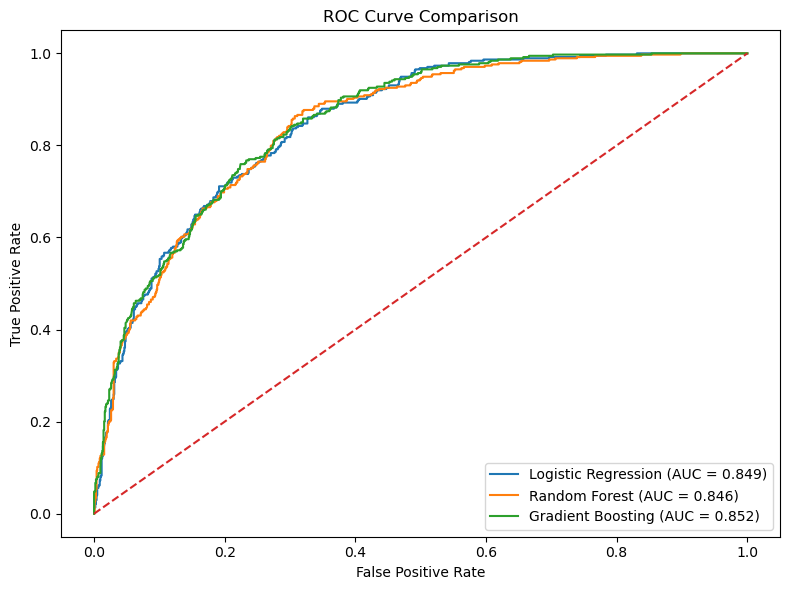

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, pipeline in trained_pipelines.items():
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    ax.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("ROC Curve Comparison")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()

plt.tight_layout()
plt.show()


## 6. Compare Precision-Recall curves

Precision-recall curves are particularly useful for churn because churners are the minority class.


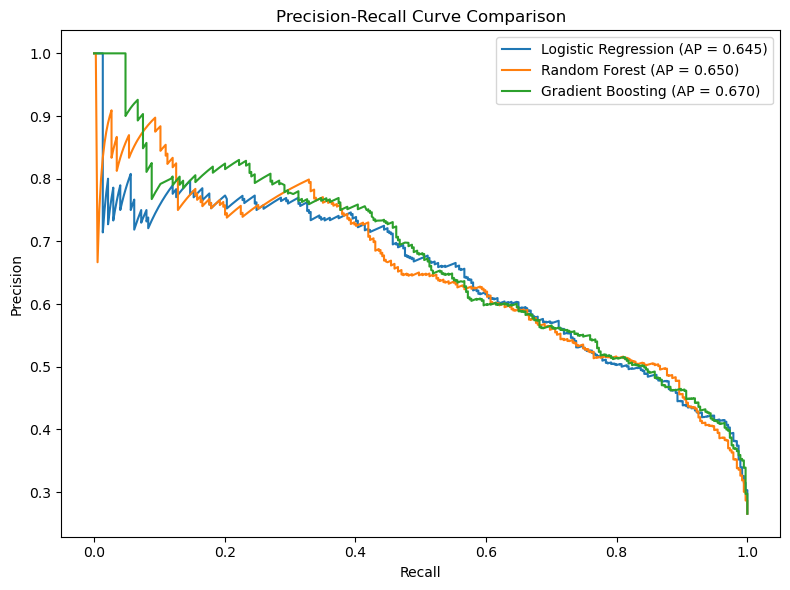

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, pipeline in trained_pipelines.items():
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)

    ax.plot(recall, precision, label=f"{model_name} (AP = {ap:.3f})")

ax.set_title("Precision-Recall Curve Comparison")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()

plt.tight_layout()
plt.show()


## 7. Select the best model

The model with the highest **ROC-AUC** on the held-out test set is selected.

This criterion is appropriate here because the later retention strategy will use predicted churn probabilities to rank customers by risk.


In [8]:
BEST_MODEL_NAME = model_performance.loc[0, "model"]
best_pipeline = trained_pipelines[BEST_MODEL_NAME]

best_y_pred = best_pipeline.predict(X_test)
best_y_prob = best_pipeline.predict_proba(X_test)[:, 1]

print(f"Selected model: {BEST_MODEL_NAME}")
print(f"ROC-AUC: {roc_auc_score(y_test, best_y_prob):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, best_y_prob):.4f}")


Selected model: Gradient Boosting
ROC-AUC: 0.8523
PR-AUC:  0.6696


## 8. Classification report


In [9]:
report = classification_report(
    y_test,
    best_y_pred,
    target_names=["Retained", "Churned"],
    digits=3,
)

print(report)


              precision    recall  f1-score   support

    Retained      0.841     0.897     0.868      1035
     Churned      0.650     0.532     0.585       374

    accuracy                          0.800      1409
   macro avg      0.746     0.714     0.727      1409
weighted avg      0.791     0.800     0.793      1409



## 9. Confusion matrix

The confusion matrix shows the trade-off between:

- correctly identifying churners;
- missing actual churners;
- incorrectly flagging retained customers as churn risks.


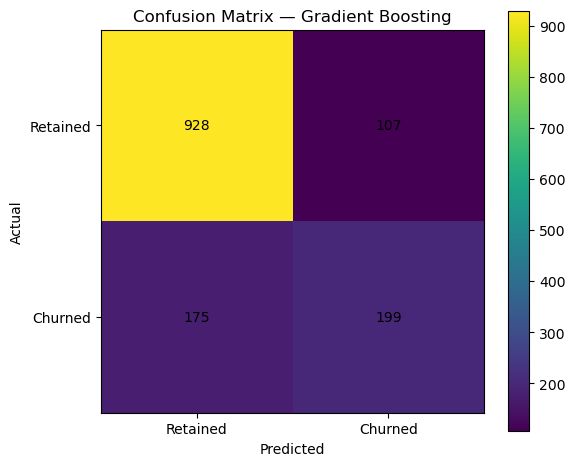

In [10]:
cm = confusion_matrix(y_test, best_y_pred)

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Retained", "Churned"])
ax.set_yticklabels(["Retained", "Churned"])

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {BEST_MODEL_NAME}")

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 10. Threshold analysis

The default probability threshold of `0.50` is not necessarily the best operational threshold for retention.

Lower thresholds identify more potential churners but also create more false positives. This table shows the trade-off at several thresholds.

The final retention strategy will primarily rank customers by probability rather than relying on one fixed threshold.


In [11]:
threshold_results = []

for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    threshold_pred = (best_y_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "customers_flagged": int(threshold_pred.sum()),
        "precision": precision_score(y_test, threshold_pred, zero_division=0),
        "recall": recall_score(y_test, threshold_pred, zero_division=0),
        "f1": f1_score(y_test, threshold_pred, zero_division=0),
    })

threshold_analysis = pd.DataFrame(threshold_results)
threshold_analysis


,threshold,customers_flagged,precision,recall,f1
0,0.3000,528,0.5436,0.7674,0.6364
1,0.4000,421,0.5867,0.6604,0.6214
2,0.5000,306,0.6503,0.5321,0.5853
3,0.6000,203,0.7537,0.4091,0.5303
4,0.7000,122,0.8033,0.2620,0.3952


## 11. Model feature importance

For interpretability, the notebook extracts feature effects directly when supported:

- Logistic Regression → absolute coefficient magnitude;
- Random Forest / Gradient Boosting → feature importance.

These values indicate predictive influence, not causal effects.


In [12]:
fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
fitted_model = best_pipeline.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()

if hasattr(fitted_model, "coef_"):
    importance_values = np.abs(fitted_model.coef_[0])
    signed_values = fitted_model.coef_[0]
    importance_type = "Absolute coefficient"
elif hasattr(fitted_model, "feature_importances_"):
    importance_values = fitted_model.feature_importances_
    signed_values = np.full(len(importance_values), np.nan)
    importance_type = "Feature importance"
else:
    importance_values = None

if importance_values is not None:
    feature_importance = pd.DataFrame({
        "feature": feature_names,
        "importance": importance_values,
        "signed_effect": signed_values,
    }).sort_values("importance", ascending=False)

    display(feature_importance.head(20))
else:
    print("Direct feature importance is not available for this model.")


,feature,importance,signed_effect
5,num__Month-to-Month,0.2891,NaN
0,num__Tenure Months,0.1423,NaN
20,cat__Internet Service_Fiber optic,0.0756,NaN
1,num__Monthly Charges,0.0744,NaN
22,cat__Online Security_No,0.0634,NaN
40,cat__Contract_Month-to-month,0.0537,NaN
2,num__Total Charges,0.0536,NaN
12,cat__Dependents_No,0.0499,NaN
31,cat__Tech Support_No,0.0463,NaN
47,cat__Payment Method_Electronic check,0.0442,NaN


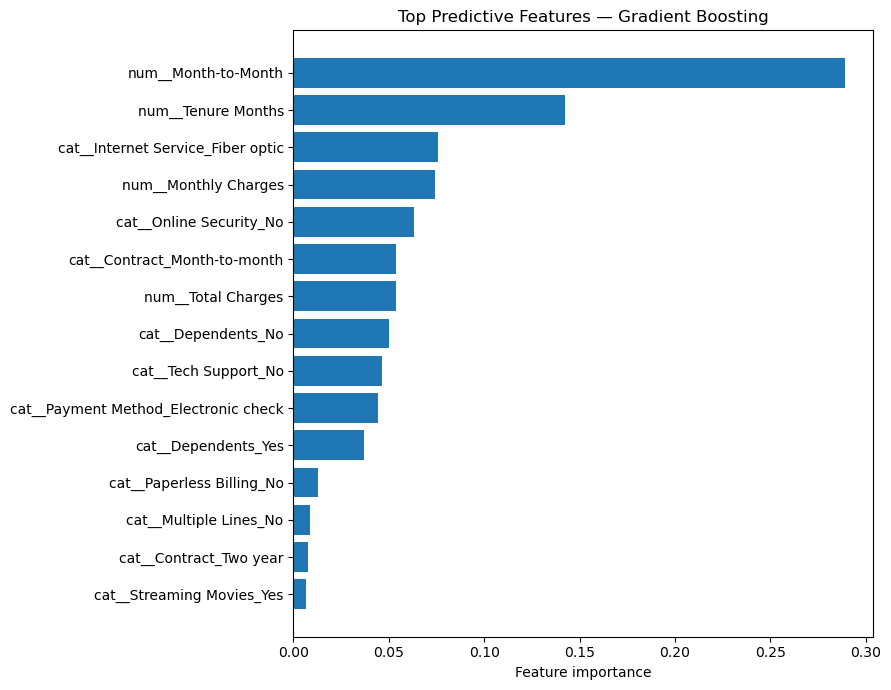

In [13]:
if importance_values is not None:
    top_features = feature_importance.head(15).sort_values("importance")

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(top_features["feature"], top_features["importance"])

    ax.set_title(f"Top Predictive Features — {BEST_MODEL_NAME}")
    ax.set_xlabel(importance_type)
    ax.set_ylabel("")

    plt.tight_layout()
    plt.show()


## 12. Generate test-set churn predictions

Each held-out customer receives:

- actual churn outcome;
- predicted churn class at threshold 0.50;
- predicted churn probability;
- risk band.

Risk bands are descriptive and will be refined in the retention strategy notebook.


In [14]:
predictions = pd.DataFrame({
    "source_index": test_index.values,
    "actual_churn": y_test.values,
    "predicted_churn": best_y_pred,
    "churn_probability": best_y_prob,
})

predictions["risk_level"] = pd.cut(
    predictions["churn_probability"],
    bins=[-np.inf, 0.30, 0.60, np.inf],
    labels=["Low", "Medium", "High"],
)

predictions = predictions.sort_values(
    "churn_probability",
    ascending=False
).reset_index(drop=True)

predictions.head(20)


,source_index,actual_churn,predicted_churn,churn_probability,risk_level
0,684,1,1,0.9300,High
1,1203,1,1,0.9226,High
2,1756,1,1,0.9224,High
3,1818,1,1,0.9223,High
4,886,1,1,0.9153,High
5,590,1,1,0.9144,High
6,641,1,1,0.9118,High
7,1681,1,1,0.9079,High
8,1387,1,1,0.9012,High
9,579,1,1,0.8957,High


## 13. Inspect high-risk customers


In [15]:
risk_summary = (
    predictions.groupby("risk_level", observed=False)
    .agg(
        customers=("source_index", "count"),
        actual_churners=("actual_churn", "sum"),
        avg_predicted_probability=("churn_probability", "mean"),
    )
)

risk_summary["actual_churn_rate"] = (
    risk_summary["actual_churners"] / risk_summary["customers"]
)

risk_summary


,customers,actual_churners,avg_predicted_probability,actual_churn_rate
risk_level,,,,
Low,881,87,0.0876,0.0988
Medium,325,134,0.4465,0.4123
High,203,153,0.7423,0.7537


## 14. Export model outputs

The following outputs are saved for the next project stage:

- `model_performance.csv`
- `threshold_analysis.csv`
- `customer_churn_predictions.csv`
- `feature_importance.csv`
- `best_churn_model.pkl`
- `best_model_metadata.json`


In [16]:
if Path("../outputs").exists() or Path("..").resolve().name == "notebooks":
    OUTPUT_DIR = Path("../outputs")
    MODEL_DIR = Path("../models")
else:
    OUTPUT_DIR = Path("outputs")
    MODEL_DIR = Path("models")

TABLE_DIR = OUTPUT_DIR / "tables"
PREDICTION_DIR = OUTPUT_DIR / "predictions"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
PREDICTION_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_performance.to_csv(
    TABLE_DIR / "model_performance.csv",
    index=False
)

threshold_analysis.to_csv(
    TABLE_DIR / "threshold_analysis.csv",
    index=False
)

predictions.to_csv(
    PREDICTION_DIR / "customer_churn_predictions.csv",
    index=False
)

if importance_values is not None:
    feature_importance.to_csv(
        TABLE_DIR / "feature_importance.csv",
        index=False
    )

joblib.dump(
    best_pipeline,
    MODEL_DIR / "best_churn_model.pkl"
)

best_model_metadata = {
    "selected_model": BEST_MODEL_NAME,
    "selection_metric": "ROC-AUC",
    "roc_auc": float(roc_auc_score(y_test, best_y_prob)),
    "pr_auc": float(average_precision_score(y_test, best_y_prob)),
    "accuracy": float(accuracy_score(y_test, best_y_pred)),
    "precision": float(precision_score(y_test, best_y_pred, zero_division=0)),
    "recall": float(recall_score(y_test, best_y_pred, zero_division=0)),
    "f1": float(f1_score(y_test, best_y_pred, zero_division=0)),
    "default_threshold": 0.50,
    "test_rows": int(len(y_test)),
}

with open(MODEL_DIR / "best_model_metadata.json", "w") as f:
    json.dump(best_model_metadata, f, indent=4)

print("Saved model outputs:")
for path in [
    TABLE_DIR / "model_performance.csv",
    TABLE_DIR / "threshold_analysis.csv",
    PREDICTION_DIR / "customer_churn_predictions.csv",
    MODEL_DIR / "best_churn_model.pkl",
    MODEL_DIR / "best_model_metadata.json",
]:
    print(f"- {path}")

if importance_values is not None:
    print(f"- {TABLE_DIR / 'feature_importance.csv'}")


Saved model outputs:
- outputs/tables/model_performance.csv
- outputs/tables/threshold_analysis.csv
- outputs/predictions/customer_churn_predictions.csv
- models/best_churn_model.pkl
- models/best_model_metadata.json
- outputs/tables/feature_importance.csv
